In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

df = pd.read_csv('../data/processed/dados_tratados.csv')

df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no-show,waiting_days
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


In [63]:
df.info()

df.columns = df.columns.str.lower()

# converter pra datetime
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

# remover horas (deixar só data)
df['scheduledday'] = df['scheduledday'].dt.date
df['appointmentday'] = df['appointmentday'].dt.date

# converter de novo pra datetime (agora sem hora)
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

# calcular tempo de espera
df['waiting_days'] = (df['appointmentday'] - df['scheduledday']).dt.days

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   patientid       110527 non-null  float64
 1   appointmentid   110527 non-null  int64  
 2   gender          110527 non-null  str    
 3   scheduledday    110527 non-null  str    
 4   appointmentday  110527 non-null  str    
 5   age             110527 non-null  int64  
 6   neighbourhood   110527 non-null  str    
 7   scholarship     110527 non-null  int64  
 8   hipertension    110527 non-null  int64  
 9   diabetes        110527 non-null  int64  
 10  alcoholism      110527 non-null  int64  
 11  handcap         110527 non-null  int64  
 12  sms_received    110527 non-null  int64  
 13  no-show         110527 non-null  str    
 14  waiting_days    110527 non-null  int64  
dtypes: float64(1), int64(9), str(5)
memory usage: 12.6 MB


,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no-show,waiting_days
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


In [64]:
df['waiting_days'].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [65]:
df['waiting_days'].mean()

np.float64(10.183701719941734)

In [66]:
df['appointmentday'].value_counts().sort_index()

appointmentday
2016-04-29    3235
2016-05-02    4376
2016-05-03    4256
2016-05-04    4168
2016-05-05    4273
2016-05-06    3879
2016-05-09    4520
2016-05-10    4308
2016-05-11    4474
2016-05-12    4394
2016-05-13    3987
2016-05-14      39
2016-05-16    4613
2016-05-17    4372
2016-05-18    4373
2016-05-19    4270
2016-05-20    3828
2016-05-24    4009
2016-05-25    3909
2016-05-30    4514
2016-05-31    4279
2016-06-01    4464
2016-06-02    4310
2016-06-03    4090
2016-06-06    4692
2016-06-07    4416
2016-06-08    4479
Name: count, dtype: int64

In [67]:
df['no-show'].value_counts()

no-show
No     88208
Yes    22319
Name: count, dtype: int64

In [68]:
df['day_of_week'] = df['appointmentday'].dt.day_name()
df.groupby('day_of_week').size()

day_of_week
Friday       19019
Monday       22715
Saturday        39
Thursday     17247
Tuesday      25640
Wednesday    25867
dtype: int64

In [69]:
df.groupby('no-show')['waiting_days'].mean()

no-show
No      8.754659
Yes    15.831489
Name: waiting_days, dtype: float64

In [70]:
df.groupby('day_of_week')['no-show'].value_counts(normalize=True)

day_of_week  no-show
Friday       No         0.787739
             Yes        0.212261
Monday       No         0.793529
             Yes        0.206471
Saturday     No         0.769231
             Yes        0.230769
Thursday     No         0.806459
             Yes        0.193541
Tuesday      No         0.799064
             Yes        0.200936
Wednesday    No         0.803108
             Yes        0.196892
Name: proportion, dtype: float64

In [71]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=order, ordered=True)

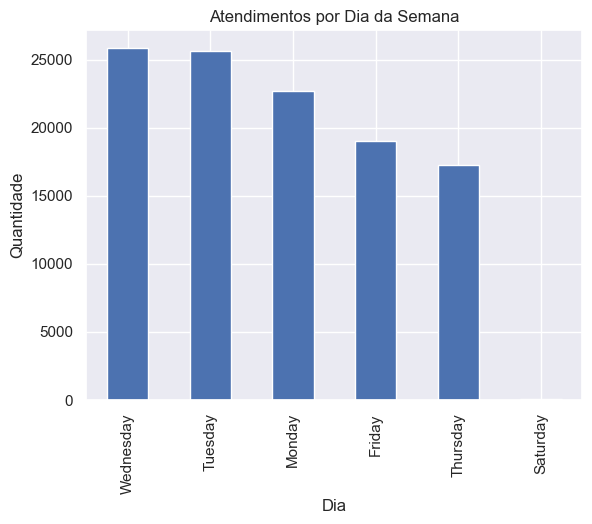

In [72]:
df['day_of_week'] = df['appointmentday'].dt.day_name()

df['day_of_week'].value_counts().plot(kind='bar')

plt.title('Atendimentos por Dia da Semana')
plt.xlabel('Dia')
plt.ylabel('Quantidade')
plt.show()

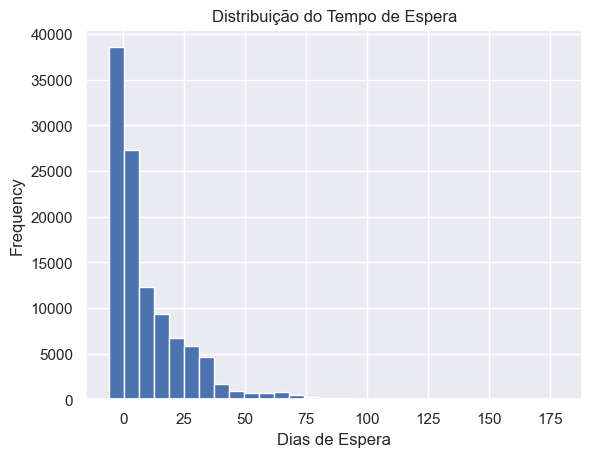

In [73]:
df['waiting_days'].plot(kind='hist', bins=30)
plt.title('Distribuição do Tempo de Espera')
plt.xlabel('Dias de Espera')
plt.show()

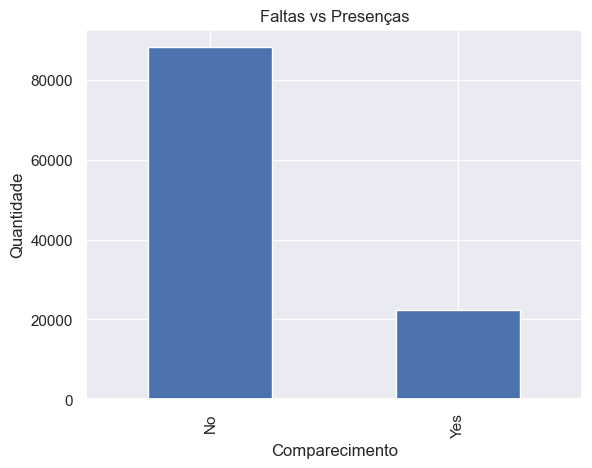

In [74]:
df['no-show'].value_counts().plot(kind='bar')
plt.title('Faltas vs Presenças')
plt.xlabel('Comparecimento')
plt.ylabel('Quantidade')
plt.show()

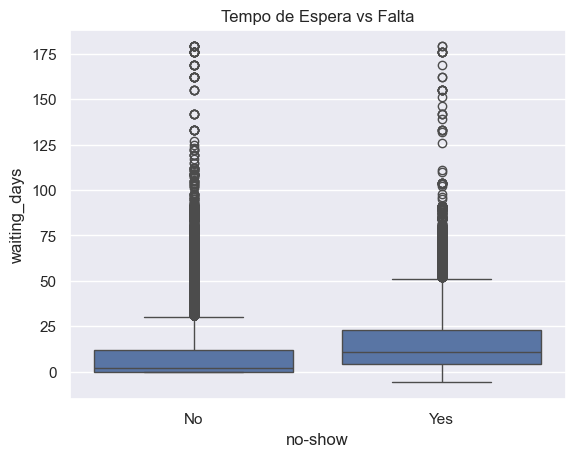

In [75]:
sns.boxplot(x='no-show', y='waiting_days', data=df)
plt.title('Tempo de Espera vs Falta')
plt.show()

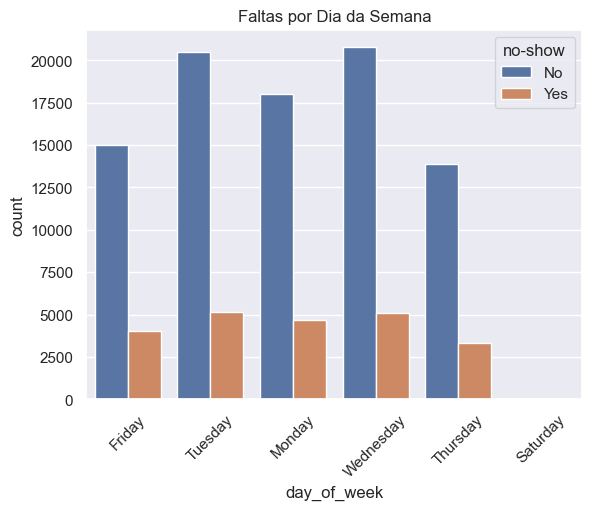

In [76]:
sns.countplot(x='day_of_week', hue='no-show', data=df)
plt.title('Faltas por Dia da Semana')
plt.xticks(rotation=45)
plt.show()

In [77]:
import sqlite3

conn = sqlite3.connect('../data/processed/dados.db')

df.to_sql('atendimentos', conn, if_exists='replace', index=False)

110527

In [78]:
query = """
SELECT day_of_week, COUNT(*) as total
FROM atendimentos
GROUP BY day_of_week
ORDER BY total DESC;
"""

pd.read_sql(query, conn)

,day_of_week,total
0,Wednesday,25867
1,Tuesday,25640
2,Monday,22715
3,Friday,19019
4,Thursday,17247
5,Saturday,39


In [79]:
query = """
SELECT 
    "no-show",
    COUNT(*) as total
FROM atendimentos
GROUP BY "no-show";
"""

pd.read_sql(query, conn)

,no-show,total
0,No,88208
1,Yes,22319


In [80]:
query = """
SELECT 
    "no-show",
    AVG(waiting_days) as media_espera
FROM atendimentos
GROUP BY "no-show";
"""

pd.read_sql(query, conn)

,no-show,media_espera
0,No,8.754659
1,Yes,15.831489


In [81]:
query = """
SELECT 
    day_of_week,
    "no-show",
    COUNT(*) as total
FROM atendimentos
GROUP BY day_of_week, "no-show"
ORDER BY day_of_week;
"""

pd.read_sql(query, conn)

,day_of_week,no-show,total
0,Friday,No,14982
1,Friday,Yes,4037
2,Monday,No,18025
3,Monday,Yes,4690
4,Saturday,No,30
5,Saturday,Yes,9
6,Thursday,No,13909
7,Thursday,Yes,3338
8,Tuesday,No,20488
9,Tuesday,Yes,5152


In [82]:
query = """
SELECT 
    neighbourhood,
    COUNT(*) as total
FROM atendimentos
GROUP BY neighbourhood
ORDER BY total DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,neighbourhood,total
0,JARDIM CAMBURI,7717
1,MARIA ORTIZ,5805
2,RESISTÊNCIA,4431
3,JARDIM DA PENHA,3877
4,ITARARÉ,3514
5,CENTRO,3334
6,TABUAZEIRO,3132
7,SANTA MARTHA,3131
8,JESUS DE NAZARETH,2853
9,BONFIM,2773


Utilizei Python para ETL e SQLite para realizar análises com SQL, simulando um ambiente de banco de dados.